In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import warnings


In [2]:
warnings.filterwarnings('ignore')

In [3]:

# ============================================
# 1. ЗАГРУЗКА И ПЕРВИЧНАЯ ОБРАБОТКА ДАННЫХ
# ============================================

def load_and_prepare_data(filepath):
  """Загружает данные и делает базовую обработку"""
  print("📂 Загрузка данных...")

  # Загружаем данные
  df = pd.read_csv(filepath)

  # Конвертируем дату
  df['date'] = pd.to_datetime(df['date'])

  # Сортируем по времени (важно для временных рядов!)
  df = df.sort_values('date').reset_index(drop=True)

  print(f"✅ Загружено {len(df)} записей")
  print(f"📅 Период: {df['date'].min()} - {df['date'].max()}")

  return df


In [4]:

# ============================================
# 1. ЗАГРУЗКА И ПЕРВИЧНАЯ ОБРАБОТКА ДАННЫХ
# ============================================

def load_and_prepare_data(filepath):
  """Загружает данные и делает базовую обработку"""
  print("📂 Загрузка данных...")

  # Загружаем данные
  df = pd.read_csv(filepath)

  # Конвертируем дату
  df['date'] = pd.to_datetime(df['date'])

  # Сортируем по времени (важно для временных рядов!)
  df = df.sort_values('date').reset_index(drop=True)

  print(f"✅ Загружено {len(df)} записей")
  print(f"📅 Период: {df['date'].min()} - {df['date'].max()}")

  return df


# ============================================
# 2. FEATURE ENGINEERING
# ============================================

def create_price_features(df):
  """Создаёт признаки из цен"""
  print("\n🔧 Создание ценовых признаков...")

  # Проверяем наличие ценовых данных
  if 'close_price' not in df.columns or df['close_price'].isna().all():
    print("⚠️  Нет данных о ценах в датасете")
    return df

  # Лаговые цены (предыдущие значения)
  df['price_lag_1h'] = df['close_price'].shift(1)
  df['price_lag_4h'] = df['close_price'].shift(4)
  df['price_lag_24h'] = df['close_price'].shift(24)
  df['price_lag_7d'] = df['close_price'].shift(168)  # 7 дней * 24 часа

  # Доходности (returns)
  df['return_1h'] = df['close_price'].pct_change(1) * 100
  df['return_4h'] = df['close_price'].pct_change(4) * 100
  df['return_24h'] = df['close_price'].pct_change(24) * 100
  df['return_7d'] = df['close_price'].pct_change(168) * 100

  # Скользящие средние
  df['ma_24h'] = df['close_price'].rolling(window=24, min_periods=1).mean()
  df['ma_7d'] = df['close_price'].rolling(window=168, min_periods=1).mean()
  df['price_vs_ma_24h'] = df['close_price'] - df['ma_24h']
  df['price_vs_ma_7d'] = df['close_price'] - df['ma_7d']

  # Волатильность
  df['volatility_24h'] = df['return_1h'].rolling(window=24, min_periods=1).std()
  df['volatility_7d'] = df['return_1h'].rolling(window=168, min_periods=1).std()

  # Диапазон цен
  if 'high_price' in df.columns and 'low_price' in df.columns:
    df['price_range_24h'] = df['high_price'].rolling(24, min_periods=1).max() - \
                            df['low_price'].rolling(24, min_periods=1).min()

  print(f"✅ Создано {df.shape[1] - len(df.columns)} ценовых признаков")
  return df



In [5]:

def create_news_features(df):
  """Создаёт признаки из новостей"""
  print("\n📰 Создание новостных признаков...")

  # Базовая обработка sentiment
  if 'sentiment' in df.columns:
    # Преобразуем sentiment в числовое значение
    sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1}
    df['sentiment_score'] = df['sentiment'].map(sentiment_map).fillna(0)
  else:
    df['sentiment_score'] = 0

  # Используем готовые sentiment колонки если есть
  if 'sentiment_positive' in df.columns:
    df['sentiment_positive'] = pd.to_numeric(df['sentiment_positive'], errors='coerce').fillna(0)
  if 'sentiment_negative' in df.columns:
    df['sentiment_negative'] = pd.to_numeric(df['sentiment_negative'], errors='coerce').fillna(0)
  if 'sentiment_neutral' in df.columns:
    df['sentiment_neutral'] = pd.to_numeric(df['sentiment_neutral'], errors='coerce').fillna(0)

  # Количество новостей за разные периоды
  df['hour'] = df['date'].dt.hour
  df['news_count_1h'] = df.groupby(df['date'].dt.floor('H')).cumcount() + 1

  # Агрегированный sentiment за скользящее окно
  df['avg_sentiment_24h'] = df['sentiment_score'].rolling(window=24, min_periods=1).mean()
  df['min_sentiment_24h'] = df['sentiment_score'].rolling(window=24, min_periods=1).min()
  df['max_sentiment_24h'] = df['sentiment_score'].rolling(window=24, min_periods=1).max()
  df['std_sentiment_24h'] = df['sentiment_score'].rolling(window=24, min_periods=1).std()

  # Ключевые слова (простой подсчёт)
  if 'title' in df.columns:
    df['title_lower'] = df['title'].fillna('').str.lower()

    # Позитивные слова
    positive_keywords = ['approved', 'adoption', 'institutional', 'etf', 'partnership', 'surge', 'rally']
    df['count_positive'] = df['title_lower'].apply(
      lambda x: sum(1 for word in positive_keywords if word in x)
    )

    # Негативные слова
    negative_keywords = ['regulation', 'banned', 'hack', 'scam', 'lawsuit', 'crash', 'shutdown']
    df['count_negative'] = df['title_lower'].apply(
      lambda x: sum(1 for word in negative_keywords if word in x)
    )

    # Нейтральные важные слова
    df['mention_sec'] = df['title_lower'].str.contains('sec').astype(int)
    df['mention_china'] = df['title_lower'].str.contains('china').astype(int)
    df['mention_walmart'] = df['title_lower'].str.contains('walmart').astype(int)

    df.drop('title_lower', axis=1, inplace=True)

  print(f"✅ Создано новостных признаков")
  return df


def create_temporal_features(df):
  """Создаёт временные признаки"""
  print("\n⏰ Создание временных признаков...")

  df['hour_of_day'] = df['date'].dt.hour
  df['day_of_week'] = df['date'].dt.dayofweek
  df['day_of_month'] = df['date'].dt.day
  df['month'] = df['date'].dt.month
  df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

  # US trading hours (примерно 14:30-21:00 UTC)
  df['is_us_trading_hours'] = ((df['hour_of_day'] >= 14) & (df['hour_of_day'] <= 21)).astype(int)

  # Asia hours (00:00-08:00 UTC)
  df['is_asia_hours'] = (df['hour_of_day'] <= 8).astype(int)

  print("✅ Создано временных признаков")
  return df


def create_targets(df, horizons=[1, 4, 24, 168]):
  """Создаёт целевые переменные (target) для разных горизонтов"""
  print("\n🎯 Создание целевых переменных...")

  if 'close_price' not in df.columns or df['close_price'].isna().all():
    print("⚠️  Нет данных о ценах для создания targets")
    return df

  for h in horizons:
    # Target = цена через h часов
    df[f'target_{h}h'] = df['close_price'].shift(-h)

  print(f"✅ Создано {len(horizons)} целевых переменных")
  return df


In [6]:

# ============================================
# 3. ПОДГОТОВКА ДАННЫХ ДЛЯ ОБУЧЕНИЯ
# ============================================

def prepare_features_and_target(df, target_col='target_1h'):
  """Подготавливает X и y для обучения"""
  print(f"\n📊 Подготовка данных для модели (target: {target_col})...")

  # Колонки, которые НЕ являются признаками
  exclude_cols = ['date', 'title', 'description', 'content', 'url', 'source',
                  'sentiment', 'Unnamed: 0', 'Links', 'subject', 'begins_at',
                  'open_price', 'close_price', 'high_price', 'low_price',
                  'symbol', 'articles', 'html', 'year', 'author',
                  'target_1h', 'target_4h', 'target_24h', 'target_168h']

  # Выбираем только числовые признаки
  feature_cols = [col for col in df.columns
                  if col not in exclude_cols and df[col].dtype in ['int64', 'float64']]

  # Удаляем строки где target = NaN (последние строки)
  df_clean = df.dropna(subset=[target_col]).copy()

  # Удаляем строки с NaN в признаках
  df_clean = df_clean[feature_cols + [target_col]].dropna()

  X = df_clean[feature_cols]
  y = df_clean[target_col]

  print(f"✅ Признаков: {X.shape[1]}, Образцов: {X.shape[0]}")
  print(f"📋 Список признаков: {feature_cols[:10]}..." if len(feature_cols) > 10 else feature_cols)

  return X, y, df_clean.index



In [7]:

# ============================================
# 4. TIME SERIES VALIDATION
# ============================================

def time_series_split(X, y, n_splits=5, test_size=0.15):
  """
  Разделяет данные на train/test + настраивает кросс-валидацию

  Схема:
  [------------- Всего данных -------------]
  [-------- 85% --------][---- 15% ----]
        Развитие             Test

  Кросс-валидация на 85%:
  Fold 1: [Train 1] → [Val 1]
  Fold 2: [Train 1+2] → [Val 2]
  Fold 3: [Train 1+2+3] → [Val 3]
  ...
  """
  print(f"\n✂️  Разделение данных (Test size: {test_size * 100}%)...")

  # Сначала отделяем test set (последние 15%)
  n = len(X)
  test_start_idx = int(n * (1 - test_size))

  X_development = X.iloc[:test_start_idx]
  y_development = y.iloc[:test_start_idx]

  X_test = X.iloc[test_start_idx:]
  y_test = y.iloc[test_start_idx:]

  print(f"📊 Development set: {len(X_development)} образцов")
  print(f"📊 Test set: {len(X_test)} образцов")

  # Time Series Cross Validation на development set
  tscv = TimeSeriesSplit(n_splits=n_splits)

  return X_development, X_test, y_development, y_test, tscv


In [8]:

# ============================================
# 5. ОБУЧЕНИЕ МОДЕЛЕЙ
# ============================================

def train_and_evaluate_models(X_dev, X_test, y_dev, y_test, tscv):
  """Обучает несколько моделей и сравнивает их"""
  print("\n🤖 Обучение моделей...\n")

  # Определяем модели
  models = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10,
                                           random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(n_estimators=200, max_depth=7, learning_rate=0.05,
                              num_leaves=63, random_state=42, verbose=-1)
  }

  results = {}

  for name, model in models.items():
    print(f"\n{'=' * 50}")
    print(f"📈 Модель: {name}")
    print(f"{'=' * 50}")

    # Кросс-валидация на development set
    cv_scores = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_dev), 1):
      X_train_fold = X_dev.iloc[train_idx]
      y_train_fold = y_dev.iloc[train_idx]
      X_val_fold = X_dev.iloc[val_idx]
      y_val_fold = y_dev.iloc[val_idx]

      # Обучаем
      model.fit(X_train_fold, y_train_fold)

      # Предсказываем на валидации
      y_pred_val = model.predict(X_val_fold)

      # Считаем MAE
      mae = mean_absolute_error(y_val_fold, y_pred_val)
      cv_scores.append(mae)

      print(f"  Fold {fold}: MAE = ${mae:.2f}")

    # Средний результат CV
    mean_cv_mae = np.mean(cv_scores)
    std_cv_mae = np.std(cv_scores)
    print(f"\n  📊 CV MAE: ${mean_cv_mae:.2f} ± ${std_cv_mae:.2f}")

    # Обучаем на всём development set
    print(f"\n  🔄 Обучение на полном development set...")
    model.fit(X_dev, y_dev)

    # Предсказываем на test set
    y_pred_test = model.predict(X_test)

    # Метрики на test set
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_r2 = r2_score(y_test, y_pred_test)
    test_mape = mean_absolute_percentage_error(y_test, y_pred_test) * 100

    # Средняя цена для процентной ошибки
    mean_price = y_test.mean()
    test_mae_percent = (test_mae / mean_price) * 100

    print(f"\n  ✅ TEST SET РЕЗУЛЬТАТЫ:")
    print(f"     MAE:  ${test_mae:.2f} ({test_mae_percent:.2f}%)")
    print(f"     RMSE: ${test_rmse:.2f}")
    print(f"     MAPE: {test_mape:.2f}%")
    print(f"     R²:   {test_r2:.4f}")

    # Сохраняем результаты
    results[name] = {
      'model': model,
      'cv_mae_mean': mean_cv_mae,
      'cv_mae_std': std_cv_mae,
      'test_mae': test_mae,
      'test_rmse': test_rmse,
      'test_mape': test_mape,
      'test_r2': test_r2,
      'test_mae_percent': test_mae_percent,
      'predictions': y_pred_test
    }

  return results


In [9]:
# ============================================
# 6. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ============================================

def plot_model_comparison(results):
  """Визуализирует сравнение моделей"""
  print("\n📊 Создание графиков сравнения...\n")

  fig, axes = plt.subplots(2, 2, figsize=(15, 10))
  fig.suptitle('Сравнение моделей', fontsize=16, fontweight='bold')

  model_names = list(results.keys())

  # 1. MAE comparison
  maes = [results[name]['test_mae'] for name in model_names]
  axes[0, 0].barh(model_names, maes, color='skyblue')
  axes[0, 0].set_xlabel('MAE ($)')
  axes[0, 0].set_title('Mean Absolute Error (Test Set)')
  axes[0, 0].grid(axis='x', alpha=0.3)

  # 2. MAPE comparison
  mapes = [results[name]['test_mape'] for name in model_names]
  axes[0, 1].barh(model_names, mapes, color='lightcoral')
  axes[0, 1].set_xlabel('MAPE (%)')
  axes[0, 1].set_title('Mean Absolute Percentage Error')
  axes[0, 1].grid(axis='x', alpha=0.3)

  # 3. R² comparison
  r2s = [results[name]['test_r2'] for name in model_names]
  axes[1, 0].barh(model_names, r2s, color='lightgreen')
  axes[1, 0].set_xlabel('R² Score')
  axes[1, 0].set_title('R² Score (Test Set)')
  axes[1, 0].grid(axis='x', alpha=0.3)

  # 4. CV MAE with error bars
  cv_means = [results[name]['cv_mae_mean'] for name in model_names]
  cv_stds = [results[name]['cv_mae_std'] for name in model_names]
  axes[1, 1].barh(model_names, cv_means, xerr=cv_stds,
                  color='plum', capsize=5)
  axes[1, 1].set_xlabel('CV MAE ($)')
  axes[1, 1].set_title('Cross-Validation MAE (с std)')
  axes[1, 1].grid(axis='x', alpha=0.3)

  plt.tight_layout()
  plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
  print("✅ График сохранён: model_comparison.png")
  plt.show()


def plot_predictions(y_test, predictions, model_name='LightGBM', n_samples=100):
  """Визуализирует предсказания vs реальные значения"""
  print(f"\n📈 Создание графика предсказаний для {model_name}...\n")

  fig, axes = plt.subplots(1, 2, figsize=(15, 5))

  # 1. Scatter plot: предсказанное vs реальное
  axes[0].scatter(y_test, predictions, alpha=0.5, s=20)
  axes[0].plot([y_test.min(), y_test.max()],
               [y_test.min(), y_test.max()],
               'r--', lw=2, label='Идеальная линия')
  axes[0].set_xlabel('Реальная цена ($)')
  axes[0].set_ylabel('Предсказанная цена ($)')
  axes[0].set_title(f'{model_name}: Предсказания vs Реальность')
  axes[0].legend()
  axes[0].grid(alpha=0.3)

  # 2. Time series: показываем последние n_samples
  y_test_subset = y_test.iloc[-n_samples:]
  predictions_subset = predictions[-n_samples:]

  axes[1].plot(range(len(y_test_subset)), y_test_subset,
               label='Реальная цена', linewidth=2)
  axes[1].plot(range(len(predictions_subset)), predictions_subset,
               label='Предсказание', linewidth=2, alpha=0.7)
  axes[1].set_xlabel('Временной индекс')
  axes[1].set_ylabel('Цена ($)')
  axes[1].set_title(f'{model_name}: Последние {n_samples} предсказаний')
  axes[1].legend()
  axes[1].grid(alpha=0.3)

  plt.tight_layout()
  plt.savefig(f'predictions_{model_name.lower().replace(" ", "_")}.png',
              dpi=300, bbox_inches='tight')
  print(f"✅ График сохранён: predictions_{model_name.lower().replace(' ', '_')}.png")
  plt.show()


def print_summary_table(results):
  """Выводит итоговую таблицу с результатами"""
  print("\n" + "=" * 80)
  print("📋 ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
  print("=" * 80)

  # Создаём DataFrame для красивого вывода
  summary_data = []
  for name, res in results.items():
    summary_data.append({
      'Модель': name,
      'CV MAE ($)': f"{res['cv_mae_mean']:.2f} ± {res['cv_mae_std']:.2f}",
      'Test MAE ($)': f"{res['test_mae']:.2f}",
      'Test MAE (%)': f"{res['test_mae_percent']:.2f}%",
      'Test MAPE (%)': f"{res['test_mape']:.2f}%",
      'Test RMSE ($)': f"{res['test_rmse']:.2f}",
      'Test R²': f"{res['test_r2']:.4f}"
    })

  summary_df = pd.DataFrame(summary_data)
  print(summary_df.to_string(index=False))
  print("=" * 80)

  # Находим лучшую модель
  best_model = min(results.items(), key=lambda x: x[1]['test_mae'])
  print(f"\n🏆 ЛУЧШАЯ МОДЕЛЬ: {best_model[0]}")
  print(f"   Test MAE: ${best_model[1]['test_mae']:.2f} ({best_model[1]['test_mae_percent']:.2f}%)")
  print(f"   Test R²: {best_model[1]['test_r2']:.4f}")


In [10]:

# ============================================
# 7. ГЛАВНАЯ ФУНКЦИЯ
# ============================================

def main():
  """Главная функция - запускает весь pipeline"""

  print("\n" + "=" * 80)
  print("🚀 BITCOIN PRICE PREDICTION - BASELINE SOLUTION")
  print("=" * 80)

  # Путь к файлу
  filepath = 'bitcoin_news_final_dataset.txt'

  # 1. Загрузка данных
  df = load_and_prepare_data(filepath)

  # 2. Feature Engineering
  df = create_price_features(df)
  df = create_news_features(df)
  df = create_temporal_features(df)
  df = create_targets(df, horizons=[1, 4, 24, 168])

  # 3. Подготовка данных для модели
  # Используем target_1h (прогноз через 1 час)
  X, y, valid_indices = prepare_features_and_target(df, target_col='target_1h')

  if len(X) == 0:
    print("\n❌ Недостаточно данных для обучения!")
    return

  # 4. Разделение на train/test + кросс-валидация
  X_dev, X_test, y_dev, y_test, tscv = time_series_split(
    X, y, n_splits=5, test_size=0.15
  )

  # 5. Обучение моделей
  results = train_and_evaluate_models(X_dev, X_test, y_dev, y_test, tscv)

  # 6. Визуализация
  plot_model_comparison(results)

  # Предсказания лучшей модели
  best_model_name = min(results.items(), key=lambda x: x[1]['test_mae'])[0]
  plot_predictions(y_test, results[best_model_name]['predictions'],
                   model_name=best_model_name)

  # 7. Итоговая таблица
  print_summary_table(results)

  print("\n✅ ГОТОВО!")
  print("=" * 80)

  return results, X_test, y_test



🚀 BITCOIN PRICE PREDICTION - BASELINE SOLUTION
📂 Загрузка данных...
✅ Загружено 9007 записей
📅 Период: 2021-11-01 15:18:00 - 2025-10-03 13:47:53

🔧 Создание ценовых признаков...
✅ Создано 0 ценовых признаков

📰 Создание новостных признаков...
✅ Создано новостных признаков

⏰ Создание временных признаков...
✅ Создано временных признаков

🎯 Создание целевых переменных...
✅ Создано 4 целевых переменных

📊 Подготовка данных для модели (target: target_1h)...
✅ Признаков: 40, Образцов: 8791
📋 Список признаков: ['sentiment_positive', 'sentiment_neutral', 'sentiment_negative', 'btc_volume', 'price_time_diff_minutes', 'btc_price_next_day', 'btc_price_change', 'btc_price_change_pct', 'btc_price_up', 'btc_volatility_pct']...

✂️  Разделение данных (Test size: 15.0%)...
📊 Development set: 7472 образцов
📊 Test set: 1319 образцов

🤖 Обучение моделей...


📈 Модель: Ridge Regression
  Fold 1: MAE = $291.72
  Fold 2: MAE = $117.46
  Fold 3: MAE = $85.01
  Fold 4: MAE = $102.14
  Fold 5: MAE = $66.14



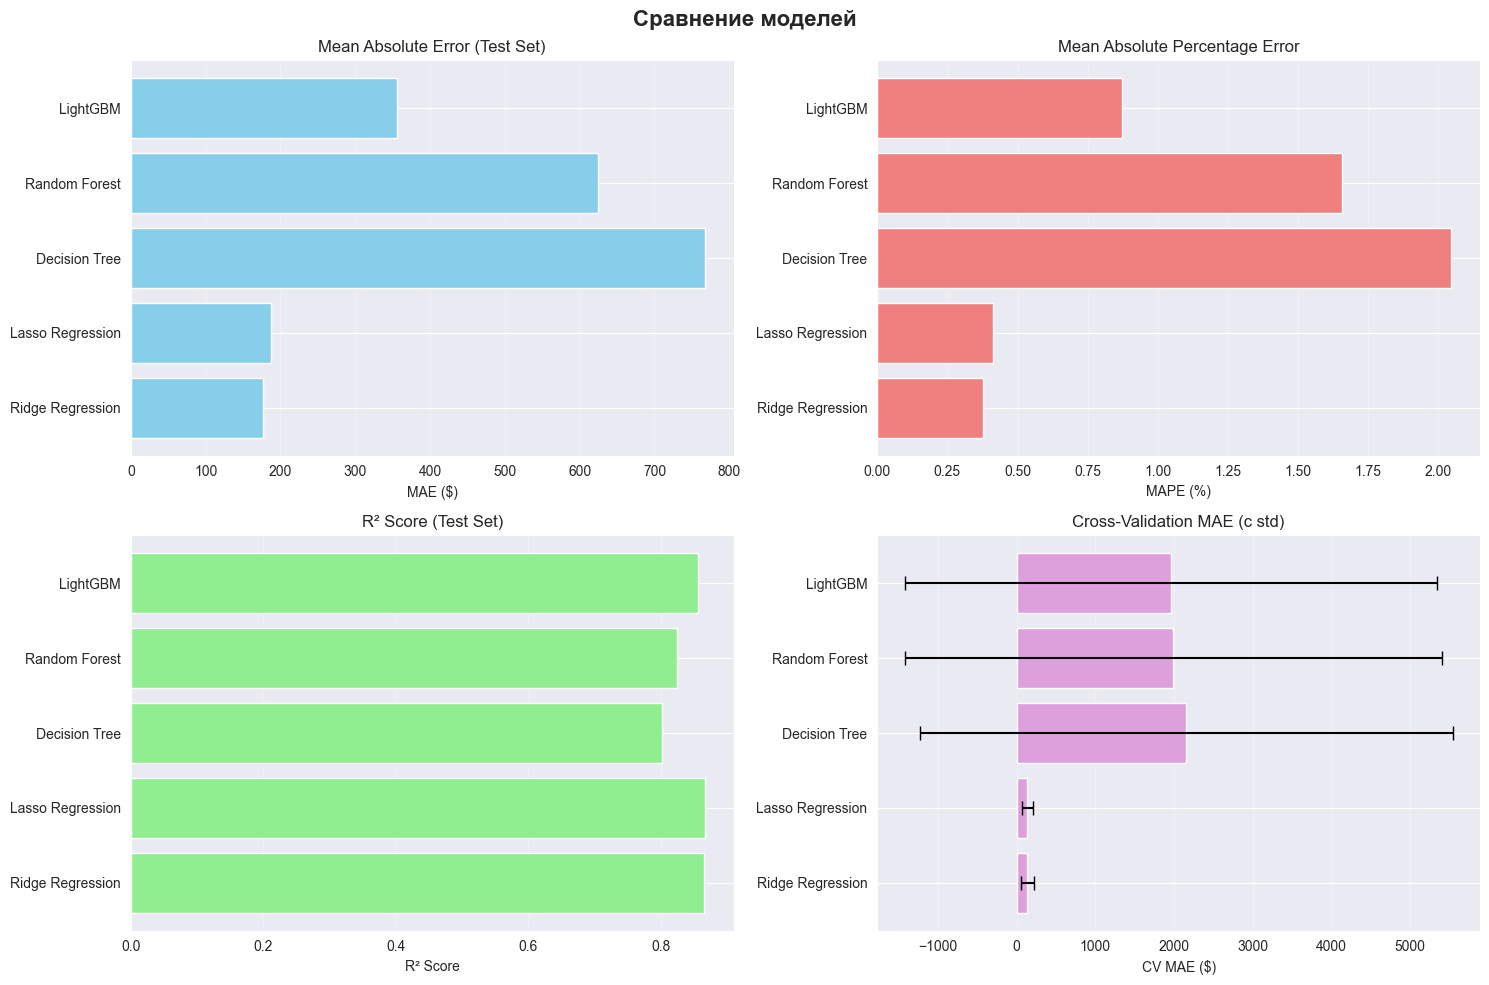


📈 Создание графика предсказаний для Ridge Regression...

✅ График сохранён: predictions_ridge_regression.png


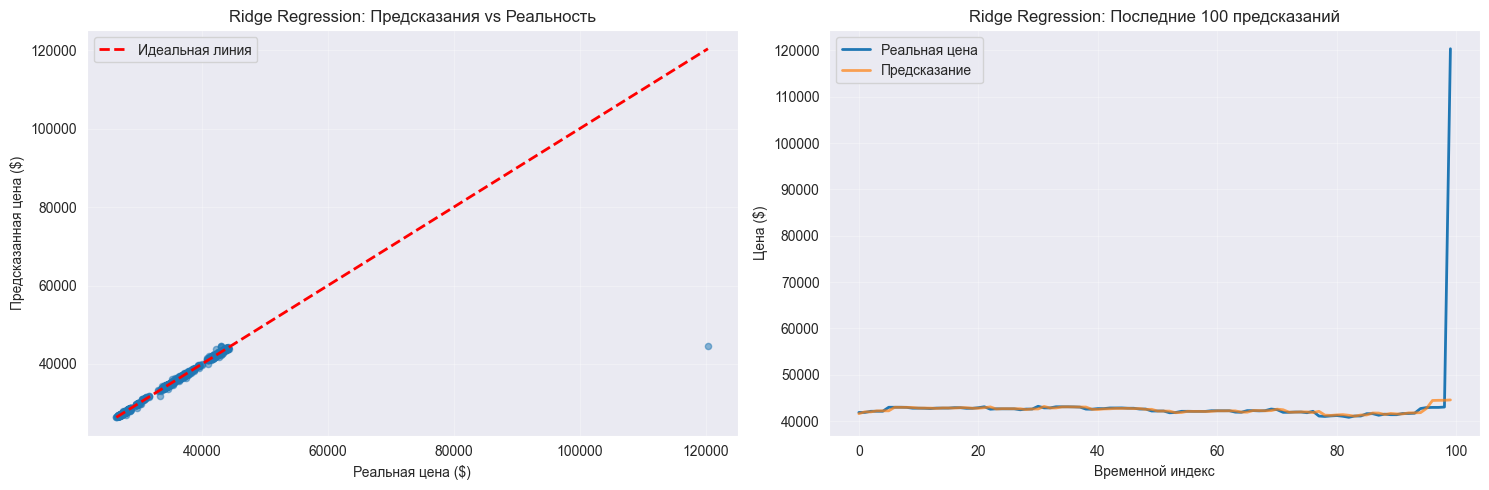


📋 ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
          Модель        CV MAE ($) Test MAE ($) Test MAE (%) Test MAPE (%) Test RMSE ($) Test R²
Ridge Regression    132.49 ± 81.43       176.51        0.49%         0.38%       2096.70  0.8658
Lasso Regression    135.97 ± 65.29       187.93        0.53%         0.41%       2087.85  0.8669
   Decision Tree 2156.73 ± 3381.51       767.44        2.15%         2.05%       2549.09  0.8016
   Random Forest 1991.31 ± 3415.57       625.10        1.75%         1.66%       2392.42  0.8253
        LightGBM 1964.44 ± 3378.38       355.70        0.99%         0.87%       2169.77  0.8563

🏆 ЛУЧШАЯ МОДЕЛЬ: Ridge Regression
   Test MAE: $176.51 (0.49%)
   Test R²: 0.8658

✅ ГОТОВО!


In [12]:
results, X_test, y_test = main()